# Conclusions-only pairwise eval: figures

Build figures from `outputs_extracted/<dataset>/<run_id>_conclusions_only/` (from `run_eval_master_conclusions_only.sh` / `run_pairwise_eval_conclusions_only.py`).

In [98]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats

def bounded_kde(vals, x_grid, low=1.0, high=5.0, bw_method=0.15):
    """KDE on [low, high] via reflection at boundaries. bw_method: bandwidth scale (<1 = less smooth)."""
    v = np.asarray(vals, dtype=float).clip(low, high)
    extended = np.concatenate([v, 2 * low - v, 2 * high - v])
    kde = scipy_stats.gaussian_kde(extended, bw_method=bw_method)
    density = kde(x_grid)
    density = np.clip(density, 0, None)
    area = np.trapz(density, x_grid)
    if area > 0:
        density = density / area
    return density

# paths (run from repo root or override)
root_dir = Path("/accounts/campus/austin.zane/stat-genie")
if not root_dir.exists():
    root_dir = Path(__file__).resolve().parents[3]
os.chdir(root_dir)

outputs_extracted = root_dir / "agentic" / "experiments" / "outputs_extracted"
figs_dir = root_dir / "agentic" / "experiments" / "insights" / "figures"
figs_dir.mkdir(parents=True, exist_ok=True)

PERTURBATIONS = [
    "add_features", "anonymize", "noperturb", "replace_with_rvs", "shuffle_names",
    "positive_leading_statement", "negative_leading_statement", "replace_and_positive_statement"
]
PERTURBATION_INDEX = {p: i for i, p in enumerate(PERTURBATIONS)}

print(outputs_extracted, "->", figs_dir)

/accounts/campus/austin.zane/stat-genie/agentic/experiments/outputs_extracted -> /accounts/campus/austin.zane/stat-genie/agentic/experiments/insights/figures


## Discover and load conclusions-only runs

In [108]:
def discover_conclusions_only_runs(base: Path):
    """Find dataset/run_id_conclusions_only dirs that contain pairwise_conclusions_only.json."""
    runs = []
    if not base.exists():
        return runs
    for dataset_dir in sorted(base.iterdir()):
        if not dataset_dir.is_dir():
            continue
        dataset = dataset_dir.name
        for path in dataset_dir.iterdir():
            if not path.is_dir() or not path.name.endswith("_conclusions_only"):
                continue
            results_file = path / "pairwise_conclusions_only.json"
            if results_file.exists():
                runs.append({"dataset": dataset, "run_dir": path, "run_id": path.name})
    return runs

runs = discover_conclusions_only_runs(outputs_extracted)
print(len(runs), "runs")
for r in runs:
    print(f'  {r["dataset"]}: {r["run_id"]}')

11 runs
  affairs: job_2883028_conclusions_only
  amtl: job_2883091_conclusions_only
  boxes: job_2883094_conclusions_only
  caschools: job_2883098_conclusions_only
  crofoot: job_2883102_conclusions_only
  hurricane: job_2883105_conclusions_only
  mortgage: job_2883109_conclusions_only
  panda_nuts: job_2883112_conclusions_only
  reading: job_2883115_conclusions_only
  soccer: job_2883118_conclusions_only
  teachingratings: job_2883121_conclusions_only


In [100]:
# Remove *_conclusions_only dirs that don't have pairwise_conclusions_only.json (keeps dirs that have it)
import shutil

to_remove = []
for dataset_dir in sorted(outputs_extracted.iterdir()):
    if not dataset_dir.is_dir():
        continue
    for path in dataset_dir.iterdir():
        if not path.is_dir() or not path.name.endswith("_conclusions_only"):
            continue
        if not (path / "pairwise_conclusions_only.json").exists():
            to_remove.append(path)

if not to_remove:
    print("Every _conclusions_only dir has pairwise_conclusions_only.json.")
else:
    for path in to_remove:
        print("removing:", path.relative_to(outputs_extracted))
        shutil.rmtree(path)
    print("removed", len(to_remove), "dirs")

Every _conclusions_only dir has pairwise_conclusions_only.json.


In [101]:
def load_run(run_dir: Path):
    with open(run_dir / "pairwise_conclusions_only.json") as f:
        pairwise = json.load(f)
    config = {}
    config_path = run_dir / "run_config.json"
    if config_path.exists():
        with open(config_path) as f:
            config = json.load(f)
    return pairwise, config

def pairwise_to_rows(pairwise: dict, dataset: str, run_id: str):
    """Flatten pairwise_conclusions_only.json into rows (pert_i, pert_j, ri, rj, overall_similarity)."""
    rows = []
    for outer_k, inner in pairwise.items():
        try:
            pi, pj = map(int, outer_k.split("_"))
        except (ValueError, TypeError):
            continue
        for inner_k, v in inner.items():
            try:
                ri, rj = map(int, inner_k.split("_"))
            except (ValueError, TypeError):
                continue
            score = v.get("overall_similarity") or v.get("conclusions")
            if score is not None:
                rows.append({
                    "dataset": dataset,
                    "run_id": run_id,
                    "pert_i": pi,
                    "pert_j": pj,
                    "pert_i_name": PERTURBATIONS[pi] if pi < len(PERTURBATIONS) else str(pi),
                    "pert_j_name": PERTURBATIONS[pj] if pj < len(PERTURBATIONS) else str(pj),
                    "ri": ri,
                    "rj": rj,
                    "overall_similarity": score,
                })
    return rows

all_rows = []
for r in runs:
    pairwise, config = load_run(r["run_dir"])
    all_rows.extend(pairwise_to_rows(pairwise, r["dataset"], r["run_id"]))

df = pd.DataFrame(all_rows)
if len(df) > 0:
    print(df.head(10))
    print("total rows:", len(df))

   dataset                        run_id  pert_i  pert_j   pert_i_name  \
0  affairs  job_2883028_conclusions_only       0       0  add_features   
1  affairs  job_2883028_conclusions_only       0       0  add_features   
2  affairs  job_2883028_conclusions_only       0       0  add_features   
3  affairs  job_2883028_conclusions_only       0       0  add_features   
4  affairs  job_2883028_conclusions_only       0       0  add_features   
5  affairs  job_2883028_conclusions_only       0       0  add_features   
6  affairs  job_2883028_conclusions_only       0       0  add_features   
7  affairs  job_2883028_conclusions_only       0       0  add_features   
8  affairs  job_2883028_conclusions_only       0       0  add_features   
9  affairs  job_2883028_conclusions_only       0       0  add_features   

    pert_j_name  ri  rj  overall_similarity  
0  add_features   0   0                   5  
1  add_features   0   1                   5  
2  add_features   0   2                   5  
3

## Figures

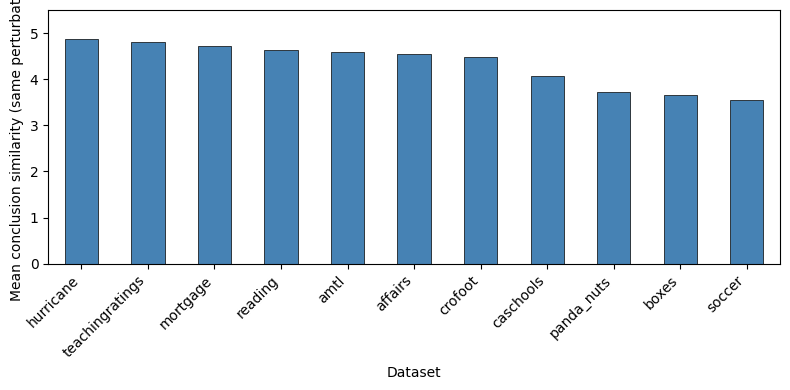

Figures saved under /accounts/campus/austin.zane/stat-genie/agentic/experiments/insights/figures


In [ ]:
if len(df) == 0:
    print("No data")
else:
    same_pert = df[(df["pert_i"] == df["pert_j"]) & (df["ri"] != df["rj"])]
    if len(same_pert) > 0:
        by_dataset = same_pert.groupby("dataset")["overall_similarity"].agg(["mean", "count"])
        by_dataset = by_dataset.sort_values("mean", ascending=False)
        fig, ax = plt.subplots(figsize=(8, 4))
        by_dataset["mean"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", linewidth=0.5)
        ax.set_ylabel("Mean conclusion similarity (same perturbation)")
        ax.set_xlabel("Dataset")
        ax.set_ylim(0, 5.5)
        ax.set_xticklabels(by_dataset.index, rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig(figs_dir / "conclusions_similarity_same_pert_by_dataset.png", bbox_inches="tight", dpi=150)
        plt.show()

    print(f"Fig saved under {figs_dir}")

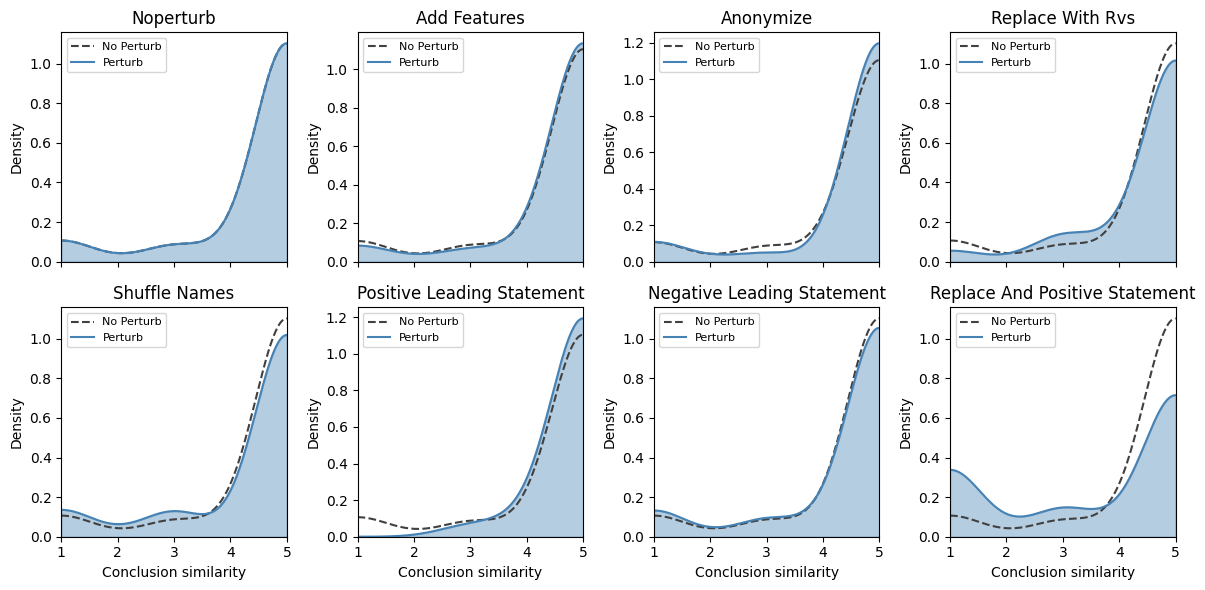

saved conclusions_kde_within_perturbation_only.png


In [ ]:
# Within-perturbation similarity KDE (noperturb overlay)
PLOT_ORDER = ["noperturb"] + [p for p in PERTURBATIONS if p != "noperturb"]
assert len(PLOT_ORDER) == 8

if len(df) == 0:
    print("No data.")
else:
    within_pert = df[(df["pert_i"] == df["pert_j"]) & (df["ri"] != df["rj"])].copy()
    within_pert["pert"] = within_pert["pert_i_name"]
    vals_noperturb = within_pert.loc[within_pert["pert"] == "noperturb", "overall_similarity"].astype(float)

    x_min, x_max = 1.0, 5.0  # hard bounds for conclusion similarity
    x_grid = np.linspace(x_min, x_max, 200)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True)
    axes = axes.flatten()

    for idx, pert_name in enumerate(PLOT_ORDER):
        ax = axes[idx]
        if len(vals_noperturb) >= 2:
            density_noperturb = bounded_kde(vals_noperturb, x_grid)
            ax.plot(x_grid, density_noperturb, color="#404040", linestyle="--", label="No Perturb", linewidth=1.5)
        vals = within_pert.loc[within_pert["pert"] == pert_name, "overall_similarity"].astype(float)
        if len(vals) >= 2:
            density = bounded_kde(vals, x_grid)
            ax.fill_between(x_grid, density, alpha=0.4, color="steelblue")
            ax.plot(x_grid, density, color="steelblue", label="Perturb", linewidth=1.5)
        ax.set_xlim(x_min, x_max)
        ax.set_ylabel("Density")
        ax.set_title(pert_name.replace("_", " ").title())
        ax.set_ylim(0, None)
        ax.legend(loc="upper left", fontsize=8)

    for j in range(4, 8):
        axes[j].set_xlabel("Conclusion similarity")
    plt.tight_layout()
    plt.savefig(figs_dir / "conclusions_kde_within_perturbation_only.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("saved conclusions_kde_within_perturbation_only.png")

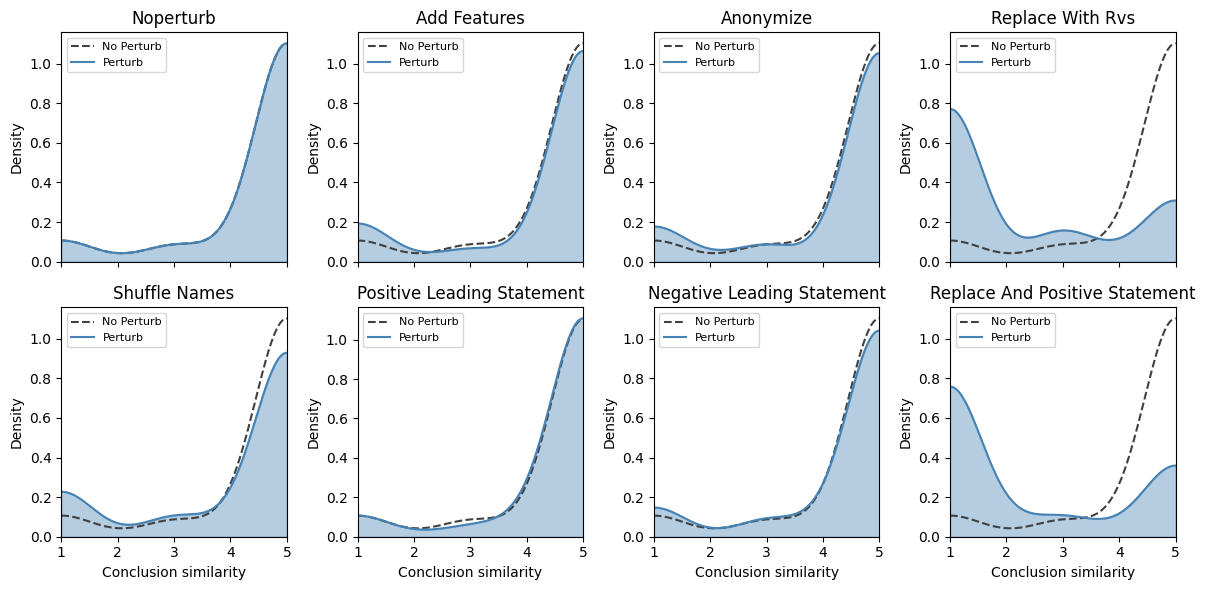

saved conclusions_kde_perturb_vs_noperturb.png


In [ ]:
# Perturb vs noperturb scores per perturbation (noperturb overlay)
NOPERTURB_IDX = PERTURBATION_INDEX["noperturb"]
PLOT_ORDER_CROSS = ["noperturb"] + [p for p in PERTURBATIONS if p != "noperturb"]

if len(df) == 0:
    print("No data.")
else:
    within_pert = df[(df["pert_i"] == df["pert_j"]) & (df["ri"] != df["rj"])].copy()
    vals_noperturb = within_pert.loc[within_pert["pert_i_name"] == "noperturb", "overall_similarity"].astype(float)

    x_min, x_max = 1.0, 5.0  # hard bounds for conclusion similarity
    x_grid = np.linspace(x_min, x_max, 200)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6), sharex=True)
    axes = axes.flatten()

    for idx, pert_name in enumerate(PLOT_ORDER_CROSS):
        ax = axes[idx]
        if len(vals_noperturb) >= 2:
            density_noperturb = bounded_kde(vals_noperturb, x_grid)
            ax.plot(x_grid, density_noperturb, color="#404040", linestyle="--", label="No Perturb", linewidth=1.5)
        p_idx = PERTURBATION_INDEX[pert_name]
        if p_idx == NOPERTURB_IDX:
            vals = vals_noperturb
        else:
            pi, pj = min(p_idx, NOPERTURB_IDX), max(p_idx, NOPERTURB_IDX)
            cross = df[(df["pert_i"] == pi) & (df["pert_j"] == pj)]
            vals = cross["overall_similarity"].astype(float)
        if len(vals) >= 2:
            density = bounded_kde(vals, x_grid)
            ax.fill_between(x_grid, density, alpha=0.4, color="steelblue")
            ax.plot(x_grid, density, color="steelblue", label="Perturb", linewidth=1.5)
        ax.set_xlim(x_min, x_max)
        ax.set_ylabel("Density")
        ax.set_title(pert_name.replace("_", " ").title())
        ax.set_ylim(0, None)
        ax.legend(loc="upper left", fontsize=8)

    for j in range(4, 8):
        axes[j].set_xlabel("Conclusion similarity")
    plt.tight_layout()
    plt.savefig(figs_dir / "conclusions_kde_perturb_vs_noperturb.png", bbox_inches="tight", dpi=150)
    plt.show()
    print("saved conclusions_kde_perturb_vs_noperturb.png")